# CA1

In [1]:
import numpy as np
import pandas as pd

from datetime import datetime

from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_validate

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import SelectFromModel

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor

from sklearn.ensemble import VotingRegressor

In [ ]:
#Setting the RNG to a constant to ensure predictability
rng = 2

In [ ]:
import os
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    drive.mount('/content/drive')
    base_dir = "./drive/My Drive/Colab Notebooks/"
else:
    base_dir = "."

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Assuming the csv file is in the same folder as the notebook
df = pd.read_csv(os.path.join(base_dir, "dataset_vehicles.csv"))

## Take a cheaky look

In [ ]:
df.head()

,Title,Sub_title,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Description,Post_URL,Seller_name,Seller_type,published_date
0,Micro Panda Auto 2019 for sale,"Posted on 02 Jul 6:27 am, Kesbewa, Colombo","Rs 2,795,000",Micro,Panda,Auto,2019,Used,Automatic,Hatchback,Petrol,"1,000 cc","14,000 km","Kesbewa, Colombo",â¤ Auto Auto Autoâ¤ Micro Panda CBH-xxxx 201...,https://ikman.lk/en/ad/micro-panda-auto-2019-f...,Sarath,Premium-Member,2021-07-02 06:27:00
1,Toyota GT86 Company Maintained 2013 for sale,"Posted on 15 Jun 7:38 pm, Rajagiriya, Colombo","Rs 11,500,000",Toyota,GT86,Company Maintained,2013,Used,Automatic,CoupÃ©/Sports,Petrol,"2,000 cc","27,000 km","Rajagiriya, Colombo",Toyota Gt86 Company maintained2013 Manufacture...,https://ikman.lk/en/ad/toyota-gt86-company-mai...,D&D Auto Parts,Premium-Member,2021-06-15 19:38:00
2,"Toyota IST FL , GRADE 2003 for sale","Posted on 05 Jul 1:36 pm, Marawila, Puttalam","Rs 3,300,000",Toyota,IST,"FL , GRADE",2003,Used,Automatic,Hatchback,Petrol,"1,300 cc","150,000 km","Marawila, Puttalam",TOYOTA ISTFL GRADEKD ; >>>> NUMBERYOM 2003RAGE...,https://ikman.lk/en/ad/toyota-ist-fl-grade-200...,Bihan Enterprises,Premium-Member,2021-07-05 13:36:00
3,Toyota Allion 240 2002 for sale,"Posted on 05 Jul 1:33 pm, Peradeniya, Kandy","Rs 4,450,000",Toyota,Allion,240,2002,Used,Automatic,Saloon,Petrol,"1,500 cc","124,000 km","Peradeniya, Kandy",Toyota Allion 240CP KA-4xxxManufactured 2002Re...,https://ikman.lk/en/ad/toyota-allion-240-2002-...,Free Bird Media (Pvt) Ltd,Premium-Member,2021-07-05 13:33:00
4,Micro Panda LC 1.0 2015 for sale,"Posted on 05 Jul 1:30 pm, Veyangoda, Gampaha","Rs 2,173,000",Micro,Panda,LC 1.0,2015,Used,Manual,Hatchback,Petrol,"1,000 cc","15,800 km","Veyangoda, Gampaha","CAJ XXXX ,Silver colour ,1st Owner , Full Opti...",https://ikman.lk/en/ad/micro-panda-lc-10-2015-...,Harsha Anuradhi,Premium-Member,2021-07-05 13:30:00


In [ ]:
df.shape

(18938, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18938 entries, 0 to 18937
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Title           18938 non-null  object
 1   Sub_title       18938 non-null  object
 2   Price           18938 non-null  object
 3   Brand           18938 non-null  object
 4   Model           18938 non-null  object
 5   Edition         13908 non-null  object
 6   Year            18938 non-null  int64 
 7   Condition       18938 non-null  object
 8   Transmission    18938 non-null  object
 9   Body            17043 non-null  object
 10  Fuel            18938 non-null  object
 11  Capacity        18938 non-null  object
 12  Mileage         18938 non-null  object
 13  Location        18938 non-null  object
 14  Description     18938 non-null  object
 15  Post_URL        18938 non-null  object
 16  Seller_name     18938 non-null  object
 17  Seller_type     18938 non-null  object
 18  publis

In [ ]:
df.describe(include="all")

,Title,Sub_title,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Description,Post_URL,Seller_name,Seller_type,published_date
count,18938,18938,18938,18938,18938,13908,18938.000000,18938,18938,17043,18938,18938,18938,18938,18938,18938,18938,18938,18938
unique,10329,17014,1831,57,516,6336,NaN,3,4,7,6,432,3850,198,17075,17911,6103,1,15060
top,Suzuki Alto 2015 for sale,"Posted on 03 Mar 11:21 am, Colombo 3, Colombo","Rs 650,000",Toyota,Alto,G Grade,NaN,Used,Automatic,Hatchback,Petrol,"1,500 cc","100,000 km","Kohuwala, Colombo",* Leasing can be arranged with your requiremen...,https://ikman.lk/en/ad/toyota-pixis-g-intelige...,LB Finance PLC,Premium-Member,2021-03-03 11:21:00
freq,184,63,92,5762,962,172,NaN,17991,11412,6712,13823,3861,450,1333,151,4,512,18938,69
mean,NaN,NaN,NaN,NaN,NaN,NaN,2007.718344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,11.640139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1927.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2003.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for column in df.columns:
    if not is_numeric_dtype(df[column]):
        print(column, df[column].value_counts())
        print()

Title Title
Suzuki Alto 2015 for sale                 184
Suzuki Wagon R Stingray 2018 for sale     138
Honda Vezel 2014 for sale                  69
Suzuki Wagon R Stingray 2017 for sale      67
Suzuki Wagon R FX 2017 for sale            57
                                         ... 
Toyota Belta (Used) 2008 for sale           1
Micro Panda 2016 2015 for sale              1
Daihatsu Leeza 1991 for sale                1
Toyota Carina SI My Road 2000 for sale      1
Maruti Zen 1995 for sale                    1
Name: count, Length: 10329, dtype: int64

Sub_title Sub_title
Posted on 03 Mar 11:21 am, Colombo 3, Colombo        63
Posted on 09 Mar 2:29 pm, Colombo 3, Colombo         62
Posted on 30 Jun 9:05 am, Matara, Matara             47
Posted on 25 Jul 2:07 pm, Matara, Matara             45
Posted on 24 May 1:53 pm, Colombo 3, Colombo         37
                                                     ..
Posted on 16 Jul 10:15 am, Boralesgamuwa, Colombo     1
Posted on 16 Jul 10:16 am, H

## Cleanup

### Duplicates

To start, not every example has a unique value for `Post_URL`. Typically I would expect this to be unique for each advert, although it is possible for two adverts that were not listed at the same time to have the same URL. However, this does suggest the possibility of duplicate examples.

I will remove all duplicate examples. I don't think we need to worry about the possibility of two adverts posted at the exact same minute by the same seller for the same vehicle with the same URL.

In [ ]:
df.drop_duplicates(inplace=True)

Now take another look at the data.

In [ ]:
df.shape

(18649, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18649 entries, 0 to 18937
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Title           18649 non-null  object
 1   Sub_title       18649 non-null  object
 2   Price           18649 non-null  object
 3   Brand           18649 non-null  object
 4   Model           18649 non-null  object
 5   Edition         13702 non-null  object
 6   Year            18649 non-null  int64 
 7   Condition       18649 non-null  object
 8   Transmission    18649 non-null  object
 9   Body            16778 non-null  object
 10  Fuel            18649 non-null  object
 11  Capacity        18649 non-null  object
 12  Mileage         18649 non-null  object
 13  Location        18649 non-null  object
 14  Description     18649 non-null  object
 15  Post_URL        18649 non-null  object
 16  Seller_name     18649 non-null  object
 17  Seller_type     18649 non-null  object
 18  published_d

In [ ]:
df.describe(include="all")

,Title,Sub_title,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Description,Post_URL,Seller_name,Seller_type,published_date
count,18649,18649,18649,18649,18649,13702,18649.000000,18649,18649,16778,18649,18649,18649,18649,18649,18649,18649,18649,18649
unique,10329,17014,1831,57,516,6336,NaN,3,4,7,6,432,3850,198,17075,17911,6103,1,15060
top,Suzuki Alto 2015 for sale,"Posted on 03 Mar 11:21 am, Colombo 3, Colombo","Rs 650,000",Toyota,Alto,G Grade,NaN,Used,Automatic,Hatchback,Petrol,"1,500 cc","100,000 km","Kohuwala, Colombo",* Leasing can be arranged with your requiremen...,https://ikman.lk/en/ad/daihatsu-mira-es-led-fa...,LB Finance PLC,Premium-Member,2021-03-03 11:21:00
freq,181,63,90,5697,944,172,NaN,17703,11315,6627,13616,3815,434,1332,151,4,512,18649,69
mean,NaN,NaN,NaN,NaN,NaN,NaN,2007.828409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,11.561233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,1927.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2003.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for column in df.columns:
    if not is_numeric_dtype(df[column]):
        print(column, df[column].value_counts())
        print()

Title Title
Suzuki Alto 2015 for sale                         181
Suzuki Wagon R Stingray 2018 for sale             137
Honda Vezel 2014 for sale                          69
Suzuki Wagon R Stingray 2017 for sale              65
Suzuki Wagon R FX 2017 for sale                    57
                                                 ... 
Toyota V8 ZX Bruno Cross 2015 for sale              1
Audi A3 TFSI Fullyloaded 2016 for sale              1
Toyota Corona 170 1991 for sale                     1
Nissan Bluebird Sylphy FG10 2004 for sale           1
Toyota Land Cruiser Prado Cygnus 2001 for sale      1
Name: count, Length: 10329, dtype: int64

Sub_title Sub_title
Posted on 03 Mar 11:21 am, Colombo 3, Colombo      63
Posted on 09 Mar 2:29 pm, Colombo 3, Colombo       62
Posted on 30 Jun 9:05 am, Matara, Matara           47
Posted on 25 Jul 2:07 pm, Matara, Matara           45
Posted on 24 May 1:53 pm, Colombo 3, Colombo       37
                                                   ..
Posted o

### Dropping columns

Looking at the head of the dataframe and the value counts, some of the columns in the dataset appear to be reduntant.

`Title` - this seems to have been generated using the brand, model, edition and year for each example.\
`Sub_title` - this seems to have been generated using the published date and location for each example.\
`Post_URL` - this seems to have been generated from the title and location for each example, with a number at the end of some, likely to prevent multiple ads up at the same time from having the same URL.\
`Seller_type` - "Premium-Member" has a frequency of 18649, so this column has the same value for all examples.

These columns contain information that can be found in other columns, or, in the case of Seller_type, information that does not differentiate an example from any other. I will drop these columns.

The `Description` column has 17075 unique values. The vast majority of examples have a unique description. From the sample descriptions we can see, it seems that much of the information provided here is vague, irrelevant, or can be found in other columns.

Although it is possible that some of the descriptions provide valuable information, the number of unique values and their unstructured nature mean it will be very difficult to gain useful insights from them, possibly requiring a separate model. I do not feel it will be fruitful to try to extract information from this column, so I am choosing to drop it.

In [ ]:
df.drop(columns=["Title", "Sub_title", "Description", "Post_URL", "Seller_type"], axis=1, inplace=True)

### Converting columns to numeric types

The columns `Price`, `Capacity` and `Mileage` contain data that is numeric, but the values are strings. Before conversion, I will need to remove the commas and units in these strings.

First, I will use the Pandas string methods to check that the values in each of these columns are all in the same units.

In [ ]:
df["Price"].str.startswith("Rs ").all()

np.True_

In [ ]:
df["Capacity"].str.endswith(" cc").all()

np.True_

In [ ]:
df["Mileage"].str.endswith(" km").all()

np.True_

Next, I will remove the commas and units from the values in each of these columns, and convert the values to integers.

In [ ]:
df["Price"] = df["Price"].str.lstrip("Rs ").str.replace(",", "").astype(int)

In [ ]:
df["Capacity"] = df["Capacity"].str.rstrip(" cc").str.replace(",", "").astype(int)

In [ ]:
df["Mileage"] = df["Mileage"].str.rstrip(" km").str.replace(",", "").astype(int)

The 'published_date' column can also be considered numeric. I feel this data will be more useful to the model if converted to a number. Since the values here specify a date and time, I will convert them to Unix timestamps (the number of seconds since midnight 1/1/1970).

In [ ]:
#Use vectorize() to create a function that can be applied to an array/series
#Create a datetime object from the string and convert it to a timestamp
to_timestamp = np.vectorize(lambda published_date: int(datetime.strptime(published_date, "%Y-%m-%d %H:%M:%S").timestamp()))
df["published_date"] = to_timestamp(df["published_date"])

### Take a cheaky look - again

In [ ]:
df.head()

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
0,2795000,Micro,Panda,Auto,2019,Used,Automatic,Hatchback,Petrol,1000,14000,"Kesbewa, Colombo",Sarath,1625207220
1,11500000,Toyota,GT86,Company Maintained,2013,Used,Automatic,CoupÃ©/Sports,Petrol,2000,27000,"Rajagiriya, Colombo",D&D Auto Parts,1623785880
2,3300000,Toyota,IST,"FL , GRADE",2003,Used,Automatic,Hatchback,Petrol,1300,150000,"Marawila, Puttalam",Bihan Enterprises,1625492160
3,4450000,Toyota,Allion,240,2002,Used,Automatic,Saloon,Petrol,1500,124000,"Peradeniya, Kandy",Free Bird Media (Pvt) Ltd,1625491980
4,2173000,Micro,Panda,LC 1.0,2015,Used,Manual,Hatchback,Petrol,1000,15800,"Veyangoda, Gampaha",Harsha Anuradhi,1625491800


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18649 entries, 0 to 18937
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           18649 non-null  int64 
 1   Brand           18649 non-null  object
 2   Model           18649 non-null  object
 3   Edition         13702 non-null  object
 4   Year            18649 non-null  int64 
 5   Condition       18649 non-null  object
 6   Transmission    18649 non-null  object
 7   Body            16778 non-null  object
 8   Fuel            18649 non-null  object
 9   Capacity        18649 non-null  int64 
 10  Mileage         18649 non-null  int64 
 11  Location        18649 non-null  object
 12  Seller_name     18649 non-null  object
 13  published_date  18649 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.1+ MB


In [ ]:
df.describe(include="all")

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
count,1.864900e+04,18649,18649,13702,18649.000000,18649,18649,16778,18649,18649.000000,18649.000000,18649,18649,1.864900e+04
unique,NaN,57,516,6336,NaN,3,4,7,6,NaN,NaN,198,6103,NaN
top,NaN,Toyota,Alto,G Grade,NaN,Used,Automatic,Hatchback,Petrol,NaN,NaN,"Kohuwala, Colombo",LB Finance PLC,NaN
freq,NaN,5697,944,172,NaN,17703,11315,6627,13616,NaN,NaN,1332,512,NaN
mean,6.449373e+06,NaN,NaN,NaN,2007.828409,NaN,NaN,NaN,NaN,1506.809159,95762.018285,NaN,NaN,1.621868e+09
std,8.607467e+06,NaN,NaN,NaN,11.561233,NaN,NaN,NaN,NaN,737.256271,76122.013355,NaN,NaN,4.811373e+06
min,9.900000e+02,NaN,NaN,NaN,1927.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,1.613173e+09
25%,2.260000e+06,NaN,NaN,NaN,2003.000000,NaN,NaN,NaN,NaN,1000.000000,45000.000000,NaN,NaN,1.617449e+09
50%,4.000000e+06,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,1490.000000,82000.000000,NaN,NaN,1.623793e+09
75%,6.900000e+06,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,1800.000000,130000.000000,NaN,NaN,1.626326e+09


In [ ]:
#Minimum for published date
datetime.fromtimestamp(np.min(df["published_date"])).strftime("%d %b %Y %I:%M %p")

'12 Feb 2021 11:30 PM'

In [ ]:
#Maximum for published date
datetime.fromtimestamp(np.max(df["published_date"])).strftime("%d %b %Y %I:%M %p")

'09 Aug 2021 11:26 PM'

### Finding invalid data

#### Numeric columns

We can see that there are some fairly extreme outliers, which will need to be dealt with later in preprocessing, however, let's first examine if any of this data can be considered to be simply invalid.

`Price`: The cheapest vehicle is Rs 990 which, according to Google, is worth less than €3 today. The most expensive is Rs 210000000, about €600,000 today.\
The upper end price is probably possible, but unless someone is really good at haggling, I would be suspicious of the lower price. I would consider Rs 200k (€500-600) to be a reasonable lower bound for price, so I will remove examples where the price is less than this (12 examples).

`Year`: The oldest vehicle advertised is from 1927, and the newest is from 2021.\
Looking at some of the older cars being advertised, there are some from each of the 1920s, 30s, 40s and 50s, so there appears to be somewhat of a vintage car market. I will not consider anything invalid based on year at this stage.

`Capacity`: Varies between 1 cc and 10000 cc.\
[According to Riiroo](https://riiroo.com/blogs/ride-on-toy-guides/what-does-cc-mean-in-motorcycles), 50 cc is considered to be the lower end of capacity *for a motorcycle*. I think we can consider cars with a capacity less than this to be invalid examples, so I will remove these (19 examples).\
[According to Guiness World Records](https://www.guinnessworldrecords.com/world-records/largest-car-engine), the largest car engine ever was 13.5L (13,500 cc). While 10,000 cc is definitely an outlier, I won't consider it invalid at this stage.

`Mileage`: See below.

`Published Date`: The dataset contains adverts posted between February and August 2021. Nothing unusual here.

In [ ]:
df[df["Price"] < 200000]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
970,990,Toyota,Vitz,NaN,2010,Used,Automatic,Hatchback,Petrol,990,112140,"Malabe, Colombo",Punchi Car Niwasa,1625309040
4235,85000,Suzuki,Wagon R Stingray,2018,2018,Used,Automatic,Hatchback,Petrol,660,28000,"Negombo, Gampaha",Azhar,1625042100
4974,165000,Nissan,Other Model,B11,1986,Used,Manual,Station wagon,Petrol,1500,100000,"Gampola, Kandy",Sellfast l Nuwaraeliya l Forest Edge,1627124880
5061,195000,Nissan,Sunny,HB310,1980,Used,Manual,Saloon,Petrol,1400,85000,"Kegalle, Kegalle",Tharindu,1627198860
5067,1500,Tata,Nano,twist,2016,Used,Manual,Hatchback,Petrol,600,7500,"Avissawella, Colombo",Riyas,1627197960
5158,2100,Hyundai,Matrix,Gls,2002,Used,Automatic,Hatchback,Petrol,1600,105000,"Dehiwala, Colombo",Mohamed,1627152900
5416,60000,Ssang Yong,Rexton,Rexton,2009,Reconditioned,Tiptronic,SUV / 4x4,Diesel,2700,0,"Colombo 6, Colombo",Onadee Motors,1627114620
5417,26000,Ssang Yong,Rexton,NaN,2009,Reconditioned,Tiptronic,SUV / 4x4,Diesel,2700,0,"Colombo 6, Colombo",Onadee Motors,1627114380
5718,115000,Nissan,Sunny,HB12,1989,Used,Manual,Saloon,Petrol,1500,235822,"Balangoda, Ratnapura",Dayasiri,1626971580
6231,160000,Nissan,Sunny,Nissan,1982,Used,Manual,Station wagon,Petrol,1400,100000,"Kegalle, Kegalle",Hansaka lakshan,1626764340


In [ ]:
df.shape

(18649, 14)

In [ ]:
#Remove examples with price less than Rs 200k
df = df[df["Price"] >= 200000]

In [ ]:
df.shape

(18637, 14)

In [ ]:
df[df["Year"] < 1960]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
45,650000,Morris,Minor,Morris minor,1947,Used,Manual,Saloon,Petrol,800,100000,"Galle, Galle",tharu deenuka,1625488380
78,600000,Morris,Minor,Classic 1955,1955,Used,Manual,Saloon,Petrol,1000,45000,"Elpitiya, Galle",Sellfast | Kreative Media | Batapola,1625486100
1452,560000,Morris,Minor,1958,1958,Used,Manual,Saloon,Petrol,1000,300000,"Kottawa, Colombo",udayangana,1625165280
1680,1250000,Ford,Other Model,Anglia,1952,Used,Manual,NaN,Petrol,720,100000,"Divulapitiya, Gampaha",Rumeth,1625073540
1767,1575000,Morris,Mini,mainer,1959,Used,Manual,Hatchback,Petrol,1000,102000,"Matara, Matara",MODEL CARS,1625207640
2398,380000,Morris,Minor,Morris Minor,1953,Used,Manual,Saloon,Petrol,1000,150009,"Galle, Galle",chathuranga sampath,1624708800
3058,1965000,Morris,Minor,NaN,1959,Used,Automatic,Hatchback,Petrol,1300,51635,"Malabe, Colombo",Mahanama Car Sales,1625203140
3243,975000,Morris,Minor,NaN,1950,Used,Manual,Hatchback,Petrol,1300,35000,"Kurunegala, Kurunegala",Nisanka Gallage,1624291320
3392,2500000,Austin,Other Model,Austin A50 1956,1956,Used,Manual,Saloon,Petrol,1500,95000,"Kadawatha, Gampaha",ravindu,1623872580
3843,1050000,Morris,Minor,NaN,1958,Used,Manual,NaN,Petrol,1100,14924,"Jaffna, Jaffna",Sureshkumar Thevarajah,1622716200


In [ ]:
df[df["Capacity"] < 50]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
776,8450000,Toyota,CHR,GT,2017,Used,Automatic,SUV / 4x4,Petrol,1,99000,"Nugegoda, Colombo",Chamila Kumarapperuma,1625338260
6281,2200000,Nissan,Leaf,G Grade,2014,Used,Automatic,Hatchback,Electric,40,100000,"Nugegoda, Colombo",Prestige Car Net,1626623280
6843,14900000,Mercedes Benz,E300,Bluetec,2014,Used,Tiptronic,Saloon,Diesel,2,57000,"Nugegoda, Colombo",Gehan,1626104160
8530,1450000,Toyota,Corolla,DX wagon,1992,Used,Manual,Station wagon,Diesel,2,235000,"Kotte, Colombo",asanka,1628371680
8967,18000000,Toyota,Hilux,Revolution,2016,Used,Tiptronic,SUV / 4x4,Diesel,2,90000,"Kurunegala, Kurunegala",Ravishanka Ariyarathna,1628176440
13845,5450000,Honda,Vezel,2014,2014,Used,Automatic,Hatchback,Petrol,2,120000,"Moratuwa, Colombo",Danusha Auto Land,1617280680
14659,2500000,Other brand,Other model,ROYCE ELECTRIC CAR,2018,New,Automatic,Convertible,Electric,4,0,"Kelaniya, Gampaha",Kamal Group,1616845800
15103,15000000,Peugeot,5008,Active Upgraded,2018,Used,Automatic,SUV / 4x4,Petrol,1,18400,"Bandaragama, Kalutara",Gamage,1616584140
15918,660000,Nissan,Sunny,NaN,1985,Used,Manual,Saloon,Petrol,1,210152,"Panadura, Kalutara",Abayasiri,1616065740
16043,7550000,Nissan,Leaf,2018 - New Model,2018,Used,Automatic,Hatchback,Electric,40,31000,"Battaramulla, Colombo",Havindra Gunawardena,1615976760


In [ ]:
df.shape

(18637, 14)

In [ ]:
#Remove examples with capacity < 50 cc
df = df[df["Capacity"] >= 50]

In [ ]:
df.shape

(18618, 14)

The values for `Mileage` vary between 0 km and 1 million km.\
0 km is possible, however, 1 million km seems a bit extreme.

It is important to take the age of the car into account here. In order to investigate this, I will calculate the mileage per year (MPY) of the vehicles.

In [ ]:
#MPY = mileage / (age of the car + 1)
#Add 1 so that cars from 2021 don't have an age of 0

#In this dataset, all cars are being sold in 2021
mpy = pd.Series(df["Mileage"] / ((2021 - df["Year"]) + 1))

In [ ]:
mpy.describe()

,0
count,18618.000000
mean,7878.287263
std,5092.133179
min,0.000000
25%,5000.000000
50%,7500.000000
75%,10111.111111
max,126666.666667


In [ ]:
df[mpy > 50000]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
4327,2000000,Suzuki,Alto,NaN,2013,Used,Manual,Hatchback,Petrol,800,800000,"Gampaha, Gampaha",Sell Fast | Ruhunupura Hardware,1624477800
4523,4450000,Mitsubishi,J24,4DR5 JEEP,2021,Used,Manual,SUV / 4x4,Diesel,2659,60000,"Kurunegala, Kurunegala",Unity Lanka Enterprises,1622731500
5499,3850000,Daihatsu,Atrai Wagon,NaN,2019,Used,Automatic,NaN,Petrol,650,380000,"Giriulla, Kurunegala",Real PC Solutions,1627061700
6413,4400000,Mitsubishi,4DR,5 J54 JEEP 1990 REG,2021,New,Manual,SUV / 4x4,Diesel,2500,66000,"Kurunegala, Kurunegala",Unity Lanka Enterprises,1626621300
6673,19800000,Mitsubishi,Montero,GLS,2015,Used,Automatic,SUV / 4x4,Diesel,3000,780000,"Boralesgamuwa, Colombo",Field Operation,1626277920
8151,2800000,Suzuki,Alto,NaN,2021,Used,Automatic,Hatchback,Petrol,650,114000,"Baddegama, Galle",Nirosha Chandrasiri,1628515500
8512,825000,Suzuki,Maruti,Maruti,2021,Used,Automatic,Hatchback,Petrol,800,65000,"Mawanella, Kegalle",manju ranasinghe,1628397660
8609,6400000,Hyundai,Tucson,NaN,2021,Used,Automatic,NaN,Petrol,2000,112000,"Dehiwala, Colombo",chandana,1628348580
10068,3999000,Daihatsu,Atrai Wagon,NaN,2019,Used,Automatic,NaN,Petrol,650,380000,"Giriulla, Kurunegala",Real PC Solutions,1628166600
10678,6300000,Mitsubishi,Montero,Sport,2018,Used,Manual,SUV / 4x4,Diesel,2500,260000,"Kadawatha, Gampaha",Suresh Indika,1618328640


[According to Donedeal](https://hello.donedeal.ie/hc/en-us/articles/24005610893457-Car-Mileage-What-You-Need-To-Know#:~:text=The%20average%20annual%20mileage%20for,to%2018%2C000%20kilometres%20per%20year.), the average car in Ireland drives between 15,000 and 18,000 km in a year. Of course, this is just an average, things could be different in Sri Lanka than in Ireland, and the MPY values here will be lower than expected since I added 1 to the age of each car. However, the rough idea seems to be reasonably accurate if not overly generous, as the mean MPY is 7,878 km and the upper quartile is 10,111 km.

I feel that I can reasonably consider cars with a MPY (as calculated here) of more than 50,000 km to be invalid examples, so I will remove these (20 examples).

In [ ]:
df.shape

(18618, 14)

In [ ]:
df = df[mpy <= 50000]
#df.drop(df[mpy_arr > 50000].index, inplace=True)

In [ ]:
df.shape

(18598, 14)

We're not quite done with mileage just yet. Let's bring in one of the nominal columns - `Condition`.

A new car should have very low mileage, but one of the 20 examples I removed above was a "new" car from 2021 with a mileage of 66,000 km.

Let's take a look at the mileage values of the new cars.

In [ ]:
new_cars = df[df["Condition"] == "New"]
new_cars["Mileage"].describe()

,Mileage
count,283.000000
mean,6698.784452
std,23000.267726
min,0.000000
25%,0.000000
50%,0.000000
75%,24.000000
max,164000.000000


The small values for most of the metrics and the large mean and max suggest there are some big outliers here.

In [ ]:
new_cars[new_cars["Mileage"] > 400]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
236,1390000,Micro,Trend,BRAND NEW,2013,New,Manual,Hatchback,Petrol,1000,125000,"Maharagama, Colombo",Kangone Motor Traders,1625474220
239,4150000,Suzuki,Wagon R FZ,Safety,2017,New,Automatic,Hatchback,Hybrid,650,16000,"Maharagama, Colombo",Kangone Motor Traders,1625474040
240,4900000,Daihatsu,Terios,NaN,2008,New,Automatic,SUV / 4x4,Petrol,1500,125000,"Maharagama, Colombo",Kangone Motor Traders,1625473920
241,4900000,Honda,Fit,GP5 grade,2014,New,Automatic,Hatchback,Hybrid,1500,71000,"Maharagama, Colombo",Kangone Motor Traders,1625473620
242,2750000,Perodua,Viva Elite,NON PRIMIUM,2010,New,Automatic,Hatchback,Petrol,1000,72000,"Maharagama, Colombo",Kangone Motor Traders,1625473320
300,3950000,Suzuki,Spacia,Custom Limited,2016,New,Automatic,MPV,Hybrid,650,80000,"Maharagama, Colombo",Kangone Motor Traders,1625473920
676,45500000,Mercedes Benz,S400,S400 Unregistered,2013,New,Tiptronic,Saloon,Hybrid,3500,2000,"Colombo 5, Colombo",CarLine Auto Mobiles,1625365500
4967,5090000,Micro,Korondo,Fully Lorded Deisel,2011,New,Automatic,SUV / 4x4,Diesel,2000,105000,"Kohuwala, Colombo",Sameera & Priyankara Auto Mart,1627212360
5042,2465000,Suzuki,Alto,Sport,2015,New,Manual,Hatchback,Petrol,800,45284,"Kesbewa, Colombo",New City Communication,1627202160
5045,4090000,Micro,Actyon,NaN,2009,New,Manual,SUV / 4x4,Diesel,1998,164000,"Kurunegala, Kurunegala",Sellfast | Uhumeeya | Gepallawa Ads,1627201740


[According to caranddriver.com](https://www.caranddriver.com/auto-loans/a31543493/how-many-miles-should-a-new-car-have/), the general rule is that a mileage of less than 200 miles (322 km) is acceptable for a new car. Based on this, I feel that any car with a mileage of more than 400 km should be not be considered new.

We could recategorise these cars, but it would be difficult to determine whether they should be considered used or reconditioned, and the veracity of these examples cannot be relied upon if the seller is trying to pass off a car with high mileage as new, so I will remove them. (40 examples)

In [ ]:
df.shape

(18598, 14)

In [ ]:
df = df[(df["Condition"] != "New") | (df["Mileage"] <= 400)]

In [ ]:
df.shape

(18558, 14)

In [ ]:
new_cars = df[df["Condition"] == "New"]
new_cars["Mileage"].describe()

,Mileage
count,243.000000
mean,18.773663
std,58.888203
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,330.000000


Before moving on, let's take a quick look at the Year values of the new cars.

In [ ]:
new_cars["Year"].describe()

,Year
count,243.000000
mean,2018.868313
std,1.545168
min,2015.000000
25%,2018.000000
50%,2019.000000
75%,2020.000000
max,2021.000000


The oldest new cars are from 2015, which I would think is a bit old for a new car, but since the mean year is 2018, I won't consider them invalid.

### Nominal columns

In [ ]:
df.shape

(18558, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18558 entries, 0 to 18937
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           18558 non-null  int64 
 1   Brand           18558 non-null  object
 2   Model           18558 non-null  object
 3   Edition         13634 non-null  object
 4   Year            18558 non-null  int64 
 5   Condition       18558 non-null  object
 6   Transmission    18558 non-null  object
 7   Body            16694 non-null  object
 8   Fuel            18558 non-null  object
 9   Capacity        18558 non-null  int64 
 10  Mileage         18558 non-null  int64 
 11  Location        18558 non-null  object
 12  Seller_name     18558 non-null  object
 13  published_date  18558 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.1+ MB


In [ ]:
df.describe(include="all")

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
count,1.855800e+04,18558,18558,13634,18558.000000,18558,18558,16694,18558,18558.000000,18558.000000,18558,18558,1.855800e+04
unique,NaN,57,515,6310,NaN,3,4,7,6,NaN,NaN,198,6081,NaN
top,NaN,Toyota,Alto,G Grade,NaN,Used,Automatic,Hatchback,Petrol,NaN,NaN,"Kohuwala, Colombo",LB Finance PLC,NaN
freq,NaN,5676,937,170,NaN,17656,11260,6588,13558,NaN,NaN,1325,512,NaN
mean,6.434744e+06,NaN,NaN,NaN,2007.812426,NaN,NaN,NaN,NaN,1508.428656,95373.810809,NaN,NaN,1.621861e+09
std,8.557270e+06,NaN,NaN,NaN,11.564668,NaN,NaN,NaN,NaN,735.807093,74007.121547,NaN,NaN,4.807964e+06
min,2.000000e+05,NaN,NaN,NaN,1927.000000,NaN,NaN,NaN,NaN,70.000000,0.000000,NaN,NaN,1.613173e+09
25%,2.265000e+06,NaN,NaN,NaN,2003.000000,NaN,NaN,NaN,NaN,1000.000000,45000.000000,NaN,NaN,1.617449e+09
50%,3.995000e+06,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,1493.000000,82000.000000,NaN,NaN,1.623773e+09
75%,6.900000e+06,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,1800.000000,130000.000000,NaN,NaN,1.626279e+09


In [ ]:
for column in ["Brand", "Condition", "Transmission", "Body", "Fuel"]:
    print(column, df[column].value_counts())
    print()

Brand Brand
Toyota           5676
Suzuki           2832
Nissan           1705
Honda            1456
Mitsubishi       1207
Mercedes Benz     607
Micro             552
BMW               450
Daihatsu          399
Land Rover        348
Hyundai           347
Kia               325
Mazda             301
Tata              253
Maruti Suzuki     241
Audi              219
Perodua           197
Peugeot           155
Ford              135
Renault            95
Volkswagen         86
Isuzu              66
DFSK               65
Chery              58
Mini               56
Datsun             52
Austin             50
Mahindra           49
Morris             49
Other brand        46
Subaru             44
Ssang Yong         44
MG                 44
Chevrolet          42
Zotye              42
Proton             38
Jaguar             31
Volvo              27
Fiat               26
Lexus              23
Daewoo             19
Maruti             18
Porsche            17
Chrysler           16
Jeep               1

In [ ]:
pd.set_option("display.max_rows", None)

In [ ]:
#You may want to collapse this
for column in ["Model", "Edition", "Location", "Seller_name"]:
    print(column, df[column].value_counts())
    print()

Streaming output truncated to the last 5000 lines.
Roy                                                                                           2
sahan jayasinghe                                                                              2
Ruchira Rasanjana                                                                             2
madushanka                                                                                    2
pushpika                                                                                      2
Nipun Weerabaddana                                                                            2
Colombo Property Management Services                                                          2
nissanka kosala                                                                               2
Sachintha Sirikumara                                                                          2
Mrs mohomed                                                                          

In [ ]:
#Reset to default
pd.set_option("display.max_rows", 60)

I will first consider `Seller_name`.

I noticed a value that seems to be the result of an error. It will not make much difference, but I will correct it anyway.

In [ ]:
df[df["Seller_name"].str.contains("http")]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
8896,31800000,Toyota,Land Cruiser Prado,TX 150,2015,Used,Automatic,SUV / 4x4,Petrol,2700,57000,"Boralesgamuwa, Colombo",Wijesinhahttps://admin.ikman.lk/review/item/ed...,1628283540


In [ ]:
df.loc[df["Seller_name"] == "Wijesinhahttps://admin.ikman.lk/review/item/edited", "Seller_name"] = "Wijesinha"

In [ ]:
df[df["Seller_name"] == "Wijesinha"]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
3124,11850000,Mercedes Benz,E250,NaN,2010,Used,Automatic,Saloon,Petrol,1600,49900,"Nugegoda, Colombo",Wijesinha,1624370820
5325,6750000,Mazda,2 Skyactive,NaN,2016,Used,Automatic,Saloon,Petrol,1300,69000,"Nugegoda, Colombo",Wijesinha,1626878580
8896,31800000,Toyota,Land Cruiser Prado,TX 150,2015,Used,Automatic,SUV / 4x4,Petrol,2700,57000,"Boralesgamuwa, Colombo",Wijesinha,1628283540


I also noticed some other values indicating missing information.

In [ ]:
seller_name_missing = np.isin(df["Seller_name"], ["..", "_", ".", "?", " ", "", "Unknown"])
df[seller_name_missing]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
1609,5400000,Hyundai,Sonata,Fully Loaded,2012,Used,Tiptronic,Saloon,Petrol,2000,63850,"Wattala, Gampaha",..,1625126880
2256,1160000,Maruti Suzuki,800,NaN,2005,Used,Manual,Hatchback,Petrol,800,73000,"Kandy, Kandy",Unknown,1624795380
9055,2900000,Nissan,Leaf,NaN,2014,Used,Automatic,Hatchback,Electric,70,50000,"Colombo 5, Colombo",..,1628269320
10745,3975000,Toyota,Prius,LIMITED EDITION,2011,Used,Automatic,Saloon,Hybrid,1500,115000,"Dehiwala, Colombo",_,1618234920


We cannot assume any of these 4 are sold by the same seller, so I will give a unique value of "Unknown seller X" to each of them.

In [ ]:
df.loc[seller_name_missing, "Seller_name"] = "Unknown seller " + np.array(["1", "2", "3", "4"])

In [ ]:
df[seller_name_missing]

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
1609,5400000,Hyundai,Sonata,Fully Loaded,2012,Used,Tiptronic,Saloon,Petrol,2000,63850,"Wattala, Gampaha",Unknown seller 1,1625126880
2256,1160000,Maruti Suzuki,800,NaN,2005,Used,Manual,Hatchback,Petrol,800,73000,"Kandy, Kandy",Unknown seller 2,1624795380
9055,2900000,Nissan,Leaf,NaN,2014,Used,Automatic,Hatchback,Electric,70,50000,"Colombo 5, Colombo",Unknown seller 3,1628269320
10745,3975000,Toyota,Prius,LIMITED EDITION,2011,Used,Automatic,Saloon,Hybrid,1500,115000,"Dehiwala, Colombo",Unknown seller 4,1618234920


`Edition` and `Body` clearly have a large number of null values, with `Edition` also having some other values indicating missing information such as "-". These will be dealt with at the preprocessing stage.

None of the other nominal columns appear to have any missing or invalid values.

## Split the dataset

I will split off 20% of the dataset to form the test set, with the remaining 80% forming the training set.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=rng)

## Exploratory Data Analysis

On a copy of the training set, I will produce a set of scatter plots and a heatmap of Pearson correlation coefficients of the columns in order to examine correlations between the various numeric features.

In [ ]:
train_copy = train.copy()

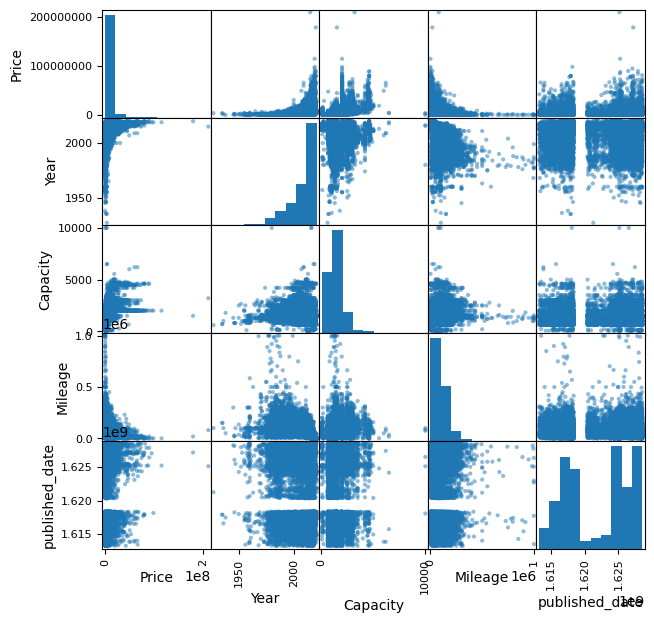

In [ ]:
scatter_matrix(train_copy, figsize=(7, 7))
plt.show()

There appears to be some kind of relation between Price and Year and between Price and Mileage, though they are far from linear. The connection between Price and Capacity seems to be less strong, and the connection between Price and published_date seems to be fairly weak.

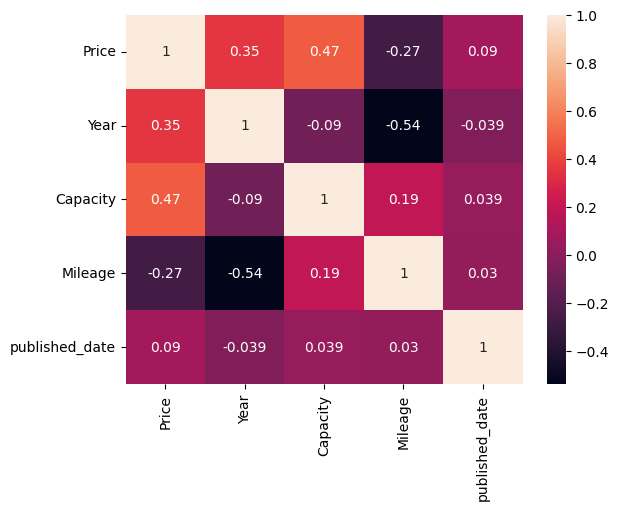

In [ ]:
sns.heatmap(train_copy.corr(numeric_only=True), annot=True)
plt.show()

The heatmap reveals that, in fact, Capacity has the strongest correlation with price of all the numeric features; the correlation coefficient of 0.47 is decently strong. There is some correlation between Price and Year and between Price and Mileage, though less strong than with Capacity. Once again, this shows there is almost no correlation between published_date and Price.

Unsurprisingly, there is a decently strong correlation between Year and Mileage. There is a somewhat weak correlation between Capacity and Mileage, and hardly any correlation between any other pair of features.

## Feature Engineering

Let's return to the idea of Mileage per Year (MPY) from earlier.

[According to the Donedeal page cited previously](https://hello.donedeal.ie/hc/en-us/articles/24005610893457-Car-Mileage-What-You-Need-To-Know), low and high mileage values raise questions regarding wear and tear, reliability and other factors. Since Year and Mileage and somewhat strongly correlated, it might make sense to consider the ratio between the car's mileage and it's age.

Once again, all the cars in this dataset are being sold in 2021, and I will add 1 to the age to avoid division by zero.

I will also try capacity / (age + 1). (There is no particular logic to this, except that dividing the numeric features by each other is a simple idea and worth trying)

In [ ]:
train_copy["Mileage_per_year"] = train_copy["Mileage"] / ((2021 - train_copy["Year"]) + 1)

In [ ]:
train_copy["Capacity_per_year"] = train_copy["Capacity"] / ((2021 - train_copy["Year"]) + 1)

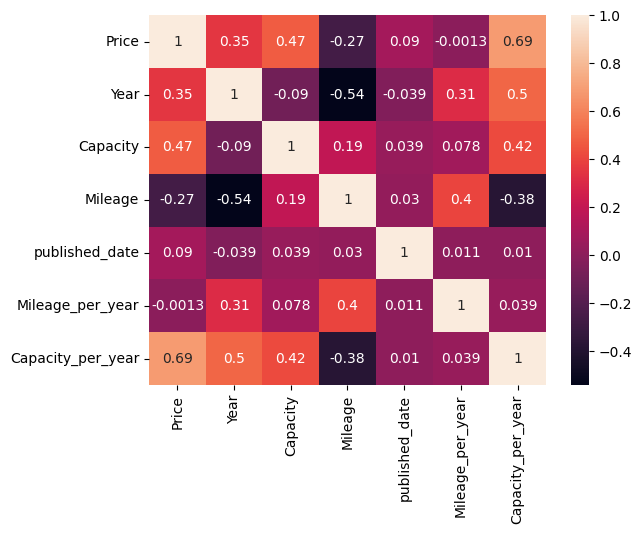

In [ ]:
sns.heatmap(train_copy.corr(numeric_only=True), annot=True)
plt.show()

MPY has a near-zero correlation with price, so this is a nonrunner. CPY turned out to be highly correlated with price, so there may be some logic to this I am not aware of.

Next, I will try the log and square of some of the numeric features, since some of them seem to have a relationship with price, but not a linear one.

In [ ]:
train_copy = train.copy()
train_copy["Log_age"] = np.log(((2021 - train_copy["Year"]) + 1))
train_copy["Log_capacity"] = np.log(train_copy["Capacity"])
train_copy["Log_mileage"] = np.log(train_copy["Mileage"] + 1)
train_copy["Age_squared"] = np.square(2021 - train_copy["Year"])
train_copy["Capacity_squared"] = np.square(train_copy["Capacity"])
train_copy["Mileage_squared"] = np.square(train_copy["Mileage"])

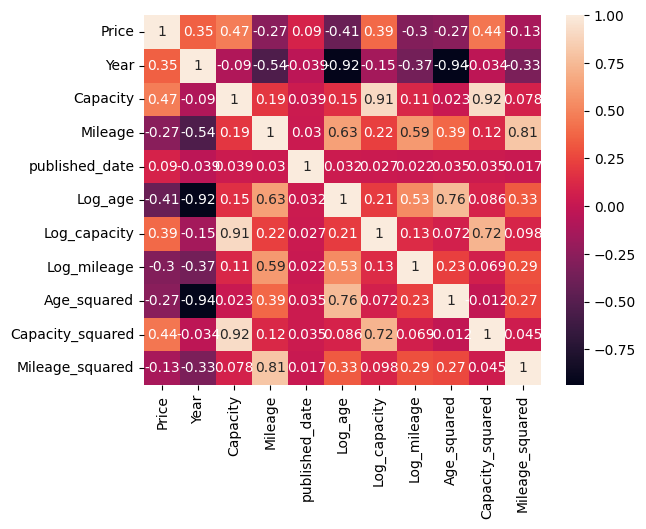

In [ ]:
sns.heatmap(train_copy.corr(numeric_only=True), annot=True)
plt.show()

Log_age and Log_mileage have a slightly better correlation than the features they are derived from, while the correlation of Log_capacity is slightly worse than that of Capacity. Each of the squares have worse correlations than the features they are derived from.

Searching the web for factors relating to car value did not yield much that could be derived from the existing features, so I turned to ChatGPT. Some of the features it suggested were:

- mileage / capacity
- age * mileage
- age * capacity

It speculated that some of these features would help capture the nonlinear depreciation of car values.

It also suggested features such as the age of the car in years and the month in which the ad was posted. These could be useful features if the dataset included ads posted in multiple different years, but I feel they are less useful in this case, as all the ads are from 2021.

In [ ]:
train_copy = train.copy()

In [ ]:
train_copy["Mileage_/_capacity"] = train_copy["Mileage"] / train_copy["Capacity"]
train_copy["Age_by_mileage"] = (2021 - train_copy["Year"]) * train_copy["Mileage"]
train_copy["Age_by_capacity"] = (2021 - train_copy["Year"]) * train_copy["Capacity"]

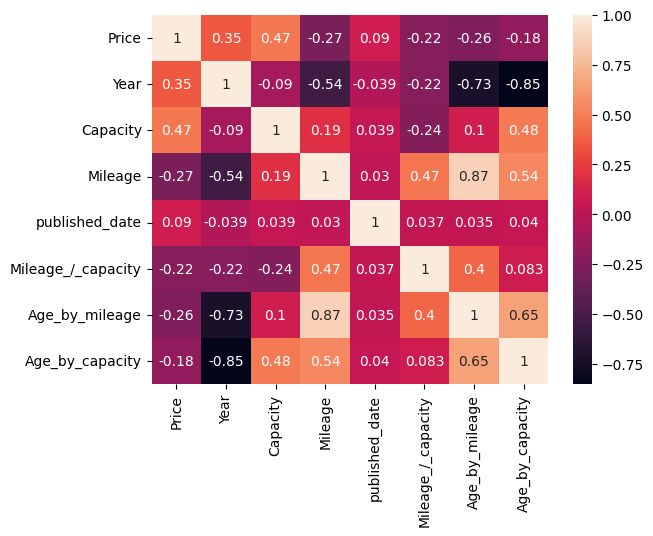

In [ ]:
sns.heatmap(train_copy.corr(numeric_only=True), annot=True)
plt.show()

None of these 4 features have a particularly strong correlation with price, so I doubt they are worth trying.

I will briefly turn to the nominal columns. From looking at some of the values for `Location` and consulting the web, it seems the second part of each location value is one of the 25 districts of Sri Lanka. It may be useful to include the district as an independent feature, as it is possible that cars are more expensive in certain districts, such as large urban areas.

In [ ]:
train_districts = train["Location"].str.split(",").str[1].str.strip()

In [ ]:
train_districts.value_counts()

,count
Location,
Colombo,7501
Gampaha,2807
Kurunegala,738
Kandy,609
Kalutara,585
Matara,503
Galle,371
Puttalam,341
Kegalle,274


I will check if my theory is correct using a list of the 25 districts from [here](http://www.commonlii.org/lk/legis/const/2000/27.html).

(Note that Monaragala was spelt slightly differently in the source)

In [ ]:
districts = ["Colombo", "Gampaha", "Kalutara", "Kandy", "Matale", "Nuwara Eliya", "Galle", "Matara", "Hambantota", "Jaffna", "Kilinochchi", "Mannar", "Vavuniya", "Mullaitivu", "Batticaloa", "Ampara", "Trincomalee", "Kurunegala", "Puttalam", "Anuradhapura", "Polonnaruwa", "Badulla", "Monaragala", "Ratnapura", "Kegalle"]

In [ ]:
np.isin(train_districts, districts).all()

np.True_

I will try the following features in the subsequent stages:

- Capacity per Year - high correlation with price
- Log_age - slightly better correlation with price than Year
- District - as a nominal features this cannot be evaluated using correlation coefficients, so I will try it in a grid search

## Preprocessing

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14846 entries, 15871 to 2584
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Price           14846 non-null  int64 
 1   Brand           14846 non-null  object
 2   Model           14846 non-null  object
 3   Edition         10902 non-null  object
 4   Year            14846 non-null  int64 
 5   Condition       14846 non-null  object
 6   Transmission    14846 non-null  object
 7   Body            13329 non-null  object
 8   Fuel            14846 non-null  object
 9   Capacity        14846 non-null  int64 
 10  Mileage         14846 non-null  int64 
 11  Location        14846 non-null  object
 12  Seller_name     14846 non-null  object
 13  published_date  14846 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 1.7+ MB


In [ ]:
train.describe(include="all")

,Price,Brand,Model,Edition,Year,Condition,Transmission,Body,Fuel,Capacity,Mileage,Location,Seller_name,published_date
count,1.484600e+04,14846,14846,10902,14846.000000,14846,14846,13329,14846,14846.000000,14846.000000,14846,14846,1.484600e+04
unique,NaN,55,497,5371,NaN,3,4,7,6,NaN,NaN,197,5145,NaN
top,NaN,Toyota,Alto,G Grade,NaN,Used,Automatic,Hatchback,Petrol,NaN,NaN,"Kohuwala, Colombo",LB Finance PLC,NaN
freq,NaN,4549,756,147,NaN,14126,9031,5277,10869,NaN,NaN,1052,425,NaN
mean,6.418085e+06,NaN,NaN,NaN,2007.864812,NaN,NaN,NaN,NaN,1501.293951,95418.587364,NaN,NaN,1.621887e+09
std,8.509826e+06,NaN,NaN,NaN,11.563516,NaN,NaN,NaN,NaN,728.404045,74588.385349,NaN,NaN,4.804136e+06
min,2.250000e+05,NaN,NaN,NaN,1927.000000,NaN,NaN,NaN,NaN,70.000000,0.000000,NaN,NaN,1.613173e+09
25%,2.260000e+06,NaN,NaN,NaN,2003.000000,NaN,NaN,NaN,NaN,1000.000000,45000.000000,NaN,NaN,1.617454e+09
50%,3.997500e+06,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,1490.000000,82000.000000,NaN,NaN,1.623835e+09
75%,6.898750e+06,NaN,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,1800.000000,130000.000000,NaN,NaN,1.626346e+09


### Columns

`Edition` and `Body` have a significant number of missing values. These are typically dealt with by deleting the examples with missing values, imputing values, or dropping the column.

In the case of `Edition`, dropping the examples with missing values is not an option, as these make up 26.5% of the training set.

Imputing the values is not feasible for this column, because:
- It has 5371 unique values, with the modal value only having a frequency of 147, and
- From looking at the values during the cleanup stage, the column does not seem to have any precise meaning. The edition can indicate the year of the car, its transmission, whether it is used or new, or anything else. It appears to mean whatever the manufacturer or seller wants it to mean.

I believe the only option is to drop the column.

For `Body`, once again the examples with missing values are too numerous to delete. Although there are only 7 unique values, the modal value of "Hatchback" only accounts for about a third of examples, and the frequency of the next most common value is still sizeable in comparison. Imputing the mode would likely mean miscategorising a large number of vehicles, so I will drop this column as well.

This leaves us with the following features:

In [ ]:
#Edition and Body are excluded
features = ["Brand", "Model", "Year", "Condition", "Transmission", "Fuel", "Capacity", "Mileage", "Location", "Seller_name", "published_date"]
numeric_features = ["Year", "Capacity", "Mileage", "published_date"]
nominal_features = ["Brand", "Model", "Transmission", "Fuel", "Location", "Seller_name"]
ordinal_features = ["Condition"]

X_train = train[features]
y_train = train["Price"]
X_test = test[features]
y_test = test["Price"]

### Outliers

Even after removing invalid examples, we can see there are still some significant outliers for most of the numeric features.

`Year` - The max of 2021 makes sense as the cars are being sold in 2021, while the min of 1927 is definitely an outlier, so I think there may be outliers at the lower end.\
`Mileage` - The min of 0 km makes sense (e.g. for a new car), while the max of 1 million km is a bit extreme, so I think there may be outliers at the upper end.\
`Capacity` - The min of 70 cc and the max of 10000 cc both seem like outliers, suggesting there are outliers at both ends.\
`Published_date` - The range of February 2021 - August 2021 makes sense, so I don't think any values should be considered outliers here.

One approach to dealing with these is to clip the outlier values based on a formula.

In [ ]:
q1 = X_train[numeric_features].quantile(0.25)
q3 = X_train[numeric_features].quantile(0.75)
iqr =  q3 - q1

low = (X_train[numeric_features] < q1 - 1.5 * iqr).sum(axis=0)
high = (X_train[numeric_features] > q3 + 1.5 * iqr).sum(axis=0)
low_or_high = ((X_train[numeric_features] < q1 - 1.5 * iqr) | (X_train[numeric_features] > q3 + 1.5 * iqr)).sum(axis=0)

print(low, high, low_or_high, sep="\n\n")

Year              747
Capacity            0
Mileage             0
published_date      0
dtype: int64

Year                0
Capacity          412
Mileage           385
published_date      0
dtype: int64

Year              747
Capacity          412
Mileage           385
published_date      0
dtype: int64


This approach lines up with what I expected, except that it doesn't consider any of the low values for capacity to be outliers, which is reasonable.

In [ ]:
(747 / len(train)), (412 / len(train)), (385 / len(train))

(0.05031658359153981, 0.0277515829179577, 0.025932911221877946)

This approach identifies 5% of values as outliers for `Year`, 2.8% for `Capacity` and 2.6% for `Mileage`.

The outliers make up relatively small proportions of the dataset, so I have my doubts about whether they would skew the model very much. I also have reservations about clipping year values in particular, considering how important the EDA suggests this feature is for determining price. Clipping may still be beneficial, so I will try it in some grid searches.

In [ ]:
class Clipper(BaseEstimator, TransformerMixin):

    def __init__(self, clip=True):
        self.clip = clip

    def fit(self, X, y=None):
        if self.clip:
            q1 = X.quantile(0.25)
            q3 = X.quantile(0.75)
            iqr =  q3 - q1
            self.min = q1 - 1.5 * iqr
            self.max = q3 + 1.5 * iqr
        return self

    def transform(self, X, y=None):
        if self.clip:
            X = X.clip(self.min, self.max, axis=1)
        return X

### Encoding nominal features

None of the nominal features have values that could be considered ordered, with the possible exception of `Condition`. For this feature, I will try both a `OneHotEncoder` and an `OrdinalEncoder` in the grid searches.

I think it makes sense to use a `OneHotEncoder` for each of the other features. However, this will result in *a lot* of new features - 5145 in the training set for `Seller_name` alone. I may need to consider feature selection in a later stage, but for now, I will limit the maximum number of categories to 500 for each feature.

### Inserting features from feature engineering

In [ ]:
class InsertCapacityPerYear(BaseEstimator, TransformerMixin):

    def __init__(self, insert=True):
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X["Capacity_per_year"] = X["Capacity"] / ((2021 - X["Year"]) + 1)
        return X

In [ ]:
class InsertLogAge(BaseEstimator, TransformerMixin):

    def __init__(self, insert=True):
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X["Log_age"] = np.log(((2021 - X["Year"]) + 1))
        return X

In [ ]:
class InsertDistrict(BaseEstimator, TransformerMixin):

    def __init__(self, insert=True):
        self.insert = insert

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if self.insert:
            X["District"] = X["Location"].str.split(",").str[1].str.strip()
        return X

### Preprocessor

In [ ]:
preprocessor_1 = ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", None)
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("district", InsertDistrict()),
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features),
        ("ord", Pipeline([
                          ("encoder", None)
                          ]), ordinal_features)
            ], remainder="drop")

## Model selection

Since this is a regression problem, I will use **mean absolute error** as the performance metric.

As for the validation method, k-fold is best for datasets of several hundred examples, while holdout is best for those with tens of thousands. This dataset is much closer to the latter, so I will use holdout.

In [ ]:
ss = ShuffleSplit(n_splits=1, test_size=0.25, random_state=rng)

I will compare my models against a dummy regressor to gauge success.

In [ ]:
dummy = DummyRegressor()

dummy.fit(X_train, y_train)

DummyRegressor()

In [ ]:
np.mean(cross_val_score(dummy, X_train, y_train, scoring="neg_mean_absolute_error", cv=ss))

np.float64(-4775566.760879855)

First, I will try the standard models most commonly used for regression: linear regression, decision trees and kNN.

In [ ]:
def grid_search(preprocessor, predictor, param_grid):
    model = Pipeline([
                ("preprocessor", preprocessor),
                ("predictor", predictor)
    ])

    gs = GridSearchCV(model, param_grid, scoring="neg_mean_absolute_error", cv=ss, n_jobs=-1)

    gs.fit(X_train, y_train)

    return gs

### Linear Regression

Since scikit-learn's implementation of linear regression is trained using the normal equation, there is no need for gradient descent. This means there are no predictor hyperparameters and it is scale invariant, so the only parameters in this grid search will be insertion of new features, clipping outliers, and which encoder to use for `Capacity`.

In [ ]:
linear_regression_gs = grid_search(
    preprocessor = preprocessor_1,
    predictor = LinearRegression(),
    param_grid = {
        "preprocessor__num__capacity_per_year__insert": [True, False],
        "preprocessor__num__log_age__insert": [True, False],
        "preprocessor__num__outliers__clip": [True, False],
        "preprocessor__num__scaler" : [None],
        "preprocessor__nom__district__insert": [True, False],
        "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()]
    }
)

linear_regression_gs.best_params_, linear_regression_gs.best_score_

({'preprocessor__nom__district__insert': True,
  'preprocessor__num__capacity_per_year__insert': True,
  'preprocessor__num__log_age__insert': True,
  'preprocessor__num__outliers__clip': False,
  'preprocessor__num__scaler': None,
  'preprocessor__ord__encoder': OrdinalEncoder()},
 np.float64(-2609324.167972874))

This model performed far better than the dummy, but still terribly, with an error of 2.6 million rupees (over €7,000).

### Decision Tree

I initially ran this with lower ranges for `predictor__max_depth`, and the grid search chose the maximum value each time. I will check the range 5-20 and then use a range with a wide step to get an idea of where the optimal value lies.

In [ ]:
# decision_tree_gs = grid_search(
#     preprocessor = preprocessor_1,
#     predictor = DecisionTreeRegressor(random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [True, False],
#         "preprocessor__num__log_age__insert": [True, False],
#         "preprocessor__num__outliers__clip": [True, False],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__nom__district__insert": [True, False],
#         "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()],
#         "predictor__max_depth": list(range(5, 20)) + list(range(20, 81, 10))
#     }
# )

# decision_tree_gs.best_params_, decision_tree_gs.best_score_

({'predictor__max_depth': 30,\
  'preprocessor__nom__district__insert': False,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': False,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OrdinalEncoder()},\
 np.float64(-929597.5184189498))

Since the range I used for `predictor__max_depth` has quite a wide step, I will run the search again with the range 21-39 to get a more precise result.

In [ ]:
# decision_tree_gs = grid_search(
#     preprocessor = preprocessor_1,
#     predictor = DecisionTreeRegressor(random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [True, False],
#         "preprocessor__num__log_age__insert": [True, False],
#         "preprocessor__num__outliers__clip": [True, False],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__nom__district__insert": [True, False],
#         "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()],
#         "predictor__max_depth": range(21, 40)
#     }
# )

# decision_tree_gs.best_params_, decision_tree_gs.best_score_

({'predictor__max_depth': 33,\
  'preprocessor__nom__district__insert': True,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': False,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OrdinalEncoder()},\
 np.float64(-923196.1827555916))

This model has a MAE of Rs 923,196 (about €2,600). This is still poor, but it is far better than the previous linear model.

In [ ]:
dt_model_1 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("outliers", Clipper()),
                          ("scaler", None)
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("district", InsertDistrict()),
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features),
        ("ord", Pipeline([
                          ("encoder", OrdinalEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", DecisionTreeRegressor(random_state=rng, max_depth=33))
])

### kNN

I will try various scalers since this is needed for kNN, and I will try the values 1-10 for `predictor__n_neighbors`.

In [ ]:
# knn_gs = grid_search(
#     preprocessor = preprocessor_1,
#     predictor = KNeighborsRegressor(),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [True, False],
#         "preprocessor__num__log_age__insert": [True, False],
#         "preprocessor__num__outliers__clip": [True, False],
#         "preprocessor__num__scaler" : [MinMaxScaler(), RobustScaler(), StandardScaler()],
#         "preprocessor__nom__district__insert": [True, False],
#         "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()],
#         "predictor__n_neighbors" : range(1, 11),
#         "predictor__weights" : ["uniform", "distance"]
#     }
# )

# knn_gs.best_params_, knn_gs.best_score_

({'predictor__n_neighbors': 6,\
  'predictor__weights': 'distance',\
  'preprocessor__nom__district__insert': False,\
  'preprocessor__num__capacity_per_year__insert': True,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': False,\
  'preprocessor__num__scaler': StandardScaler(),\
  'preprocessor__ord__encoder': OneHotEncoder()},\
 np.float64(-939973.1511220234))

This error (about €2,600) is still much better than the linear model, but a bit worse than the decision tree.

In [ ]:
knn_model_1 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("scaler", StandardScaler())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features),
        ("ord", Pipeline([
                          ("encoder", OneHotEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", KNeighborsRegressor(n_neighbors=6, weights="distance", n_jobs=-1))
])

### Checking fits

These 3 models are all doing fairy poorly. I will try some other models, but first I will check each of the ones I have for under- and overfitting to get an idea of where to go from here.

In [ ]:
def check_fit(model):
    scores = cross_validate(model, X_train, y_train, cv=ss, scoring="neg_mean_absolute_error", return_train_score=True, n_jobs=-1)
    return scores["train_score"].mean(), scores["test_score"].mean()

In [ ]:
check_fit(linear_regression_gs.best_estimator_)

(np.float64(-2680828.697813695), np.float64(-2609324.167972874))

The training and validation errors for the linear regression model are both awful, so it is clearly underfitting.

In [ ]:
check_fit(dt_model_1)

(np.float64(-13823.828048070474), np.float64(-923196.1827555916))

The decision tree training error is small at Rs 13,823 (about €40), while the validation error is huge in comparison, so this is clearly overfitting.

In [ ]:
check_fit(knn_model_1)

(np.float64(-49.39823962636968), np.float64(-939973.1511220234))

The kNN model is also overfitting.

### Manual Feature Selection

As mentioned, the one hot encoding of several nominal columns means this dataset has many features, so feature selection is likely worth trying. This could also be a potential solution to the overfitting in the decision tree and kNN models.

Before I try any algorithms, I will try some manual feature selection and see how it performs. I will try excluding the `Location` and `Seller_name` columns, as these have a high number of unique values (this also means excluding the `District` feature derived from `Location`).

In [ ]:
nominal_features_reduced = ["Brand", "Model", "Transmission", "Fuel"]

In [ ]:
preprocessor_2 = ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", None)
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", None)
                          ]), ordinal_features)
            ], remainder="drop")

I will repeat some of the previous grid searches to see what difference this makes.

In [ ]:
linear_regression_gs_2 = grid_search(
    preprocessor = preprocessor_2,
    predictor = LinearRegression(),
    param_grid = {
        "preprocessor__num__capacity_per_year__insert": [True, False],
        "preprocessor__num__log_age__insert": [True, False],
        "preprocessor__num__outliers__clip": [True, False],
        "preprocessor__num__scaler" : [None],
        "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()]
    }
)

linear_regression_gs_2.best_params_, linear_regression_gs_2.best_score_

({'preprocessor__num__capacity_per_year__insert': True,
  'preprocessor__num__log_age__insert': True,
  'preprocessor__num__outliers__clip': False,
  'preprocessor__num__scaler': None,
  'preprocessor__ord__encoder': OrdinalEncoder()},
 np.float64(-2609328.9018779434))

Based on the result of the previous decision tree grid searches, I will use the range 28-37 for `"predictor__max_depth"`.

In [ ]:
# decision_tree_gs_2 = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = DecisionTreeRegressor(random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [True, False],
#         "preprocessor__num__log_age__insert": [True, False],
#         "preprocessor__num__outliers__clip": [True, False],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()],
#         "predictor__max_depth": range(28, 38)
#     }
# )

# decision_tree_gs_2.best_params_, decision_tree_gs_2.best_score_

({'predictor__max_depth': 32,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OneHotEncoder()},\
 np.float64(-844916.1144387668))

In [ ]:
# check_fit(decision_tree_gs_2.best_estimator_)

(np.float64(-10297.10417478016), np.float64(-844916.1144387668))

Before I run the expensive kNN grid search again, I will change the previous winning model to exclude these features, in order to get a rough idea of whether this will be succesful.

In [ ]:
knn_model_2_test = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("scaler", StandardScaler())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OneHotEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", KNeighborsRegressor(n_neighbors=6, weights="distance", n_jobs=-1))
])

In [ ]:
check_fit(knn_model_2_test)

(np.float64(-49.39823962636968), np.float64(-804634.840799327))

Looks good to me. Let's run the grid search.

In [ ]:
# knn_gs_2 = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = KNeighborsRegressor(),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [True, False],
#         "preprocessor__num__log_age__insert": [True, False],
#         "preprocessor__num__outliers__clip": [True, False],
#         "preprocessor__num__scaler" : [MinMaxScaler(), RobustScaler(), StandardScaler()],
#         "preprocessor__ord__encoder": [OrdinalEncoder(), OneHotEncoder()],
#         "predictor__n_neighbors" : range(1, 11),
#         "predictor__weights" : ["uniform", "distance"]
#     }
# )

# knn_gs_2.best_params_, knn_gs_2.best_score_

({'predictor__n_neighbors': 3,\
  'predictor__weights': 'distance',\
  'preprocessor__num__capacity_per_year__insert': True,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': RobustScaler(),\
  'preprocessor__ord__encoder': OrdinalEncoder()},\
 np.float64(-758589.8499897408))

In [ ]:
knn_model_2 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("scaler", RobustScaler()),
                          ("outliers", Clipper())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OrdinalEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", KNeighborsRegressor(n_neighbors=3, weights="distance", n_jobs=-1))
])

In [ ]:
# check_fit(knn_model_2)

(np.float64(-49.39823962636968), np.float64(-758589.8499897408))

This change made the linear regression model slightly worse (probably because it was underfitting rather than overfitting), but made a big improvement to the decision tree model and an even bigger improvement to the kNN model.

### Feature Selection Algorithms

For the decision tree and kNN, the manual feature selection seems to have been helpful, but they are still overfitting. There are still many features, so I will now try some feature selection algorithms in addition to this.

I won't use regularization since the linear regression model is underfitting rather than overfitting, and I won't use sequential feature selection algorithms since they will likely be very expensive on this dataset, but I will try filter methods.

I will consider the `SelectKBest` class using the `f_regression` function and `SelectFromModel` using a random forest.

To get an idea of which to choose, I will keep the parameters of the previous winners the same except for max depth/number of neighbors and just let the grid searches decide these, as well as how many features to keep.

First, `SelectKBest`.

In [ ]:
preprocessor_skb = Pipeline([
     ("pre", preprocessor_2),
     ("f_selector", SelectKBest(score_func=f_regression, k=None))
])

In [ ]:
# decision_tree_gs_skb = grid_search(
#     preprocessor = preprocessor_skb,
#     predictor = DecisionTreeRegressor(random_state=rng),
#     param_grid = {
#         "preprocessor__pre__num__capacity_per_year__insert": [False],
#         "preprocessor__pre__num__log_age__insert": [True],
#         "preprocessor__pre__num__outliers__clip": [True],
#         "preprocessor__pre__num__scaler" : [None],
#         "preprocessor__pre__ord__encoder": [OneHotEncoder()],
#         "preprocessor__f_selector__k": [5, 10, 20, 50, 100, 150, 200, 300, 500, 1000],     #1000 will return all the features
#         "predictor__max_depth": range(28, 38)
#     }
# )

# decision_tree_gs_skb.best_params_, decision_tree_gs_skb.best_score_

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=570. All the features will be returned.\
  warnings.warn(\
({'predictor__max_depth': 32,\
  'preprocessor__f_selector__k': 1000,\
  'preprocessor__pre__num__capacity_per_year__insert': False,\
  'preprocessor__pre__num__log_age__insert': True,\
  'preprocessor__pre__num__outliers__clip': True,\
  'preprocessor__pre__num__scaler': None,\
  'preprocessor__pre__ord__encoder': OneHotEncoder()},\
 np.float64(-844916.1144387668))

In [ ]:
# knn_gs_skb = grid_search(
#     preprocessor = preprocessor_skb,
#     predictor = KNeighborsRegressor(),
#     param_grid = {
#         "preprocessor__pre__num__capacity_per_year__insert": [True],
#         "preprocessor__pre__num__log_age__insert": [True],
#         "preprocessor__pre__num__outliers__clip": [True],
#         "preprocessor__pre__num__scaler" : [RobustScaler()],
#         "preprocessor__pre__ord__encoder": [OrdinalEncoder()],
#         "preprocessor__f_selector__k": [50, 100, 150, 200, 300, 500],
#         "predictor__n_neighbors" : range(1, 6),
#         "predictor__weights" : ["distance"]
#     }
# )

# knn_gs_skb.best_params_, knn_gs_skb.best_score_

({'predictor__n_neighbors': 3,\
  'predictor__weights': 'distance',
  'preprocessor__f_selector__k': 500,\
  'preprocessor__pre__num__capacity_per_year__insert': True,\
  'preprocessor__pre__num__log_age__insert': True,\
  'preprocessor__pre__num__outliers__clip': True,\
  'preprocessor__pre__num__scaler': RobustScaler(),\
  'preprocessor__pre__ord__encoder': OrdinalEncoder()},\
 np.float64(-761236.1123661092))

With these parameters, reducing the number of features with `SelectKBest` did not reduce the error for either model.

Next, `SelectFromModel`.

In [ ]:
preprocessor_sfm = Pipeline([
     ("pre", preprocessor_2),
     ("f_selector", SelectFromModel(estimator=RandomForestRegressor(n_estimators=100, max_depth=2, random_state=rng), max_features=None))
])

In [ ]:
# decision_tree_gs_sfm = grid_search(
#     preprocessor = preprocessor_sfm,
#     predictor = DecisionTreeRegressor(random_state=rng),
#     param_grid = {
#         "preprocessor__pre__num__capacity_per_year__insert": [False],
#         "preprocessor__pre__num__log_age__insert": [True],
#         "preprocessor__pre__num__outliers__clip": [True],
#         "preprocessor__pre__num__scaler" : [None],
#         "preprocessor__pre__ord__encoder": [OneHotEncoder()],
#         "preprocessor__f_selector__max_features": [5, 10, 20, 50, 100, 150, 200, 300, 500],
#         "predictor__max_depth": range(28, 38)
#     }
# )

# decision_tree_gs_sfm.best_params_, decision_tree_gs_sfm.best_score_

({'predictor__max_depth': 28,\
  'preprocessor__f_selector__max_features': 5,\
  'preprocessor__pre__num__capacity_per_year__insert': False,\
  'preprocessor__pre__num__log_age__insert': True,\
  'preprocessor__pre__num__outliers__clip': True,\
  'preprocessor__pre__num__scaler': None,\
  'preprocessor__pre__ord__encoder': OneHotEncoder()},\
 np.float64(-1498036.4362176452))

In [ ]:
# knn_gs_sfm = grid_search(
#     preprocessor = preprocessor_sfm,
#     predictor = KNeighborsRegressor(),
#     param_grid = {
#         "preprocessor__pre__num__capacity_per_year__insert": [True],
#         "preprocessor__pre__num__log_age__insert": [True],
#         "preprocessor__pre__num__outliers__clip": [True],
#         "preprocessor__pre__num__scaler" : [RobustScaler()],
#         "preprocessor__pre__ord__encoder": [OrdinalEncoder()],
#         "preprocessor__f_selector__max_features": [5, 10, 20, 50, 100, 150, 200, 300, 500],
#         "predictor__n_neighbors" : range(1, 6),
#         "predictor__weights" : ["distance"]
#     }
# )

# knn_gs_sfm.best_params_, knn_gs_sfm.best_score_

({'predictor__n_neighbors': 4,\
  'predictor__weights': 'distance',\
  'preprocessor__f_selector__max_features': 50,\
  'preprocessor__pre__num__capacity_per_year__insert': True,\
  'preprocessor__pre__num__log_age__insert': True,\
  'preprocessor__pre__num__outliers__clip': True,\
  'preprocessor__pre__num__scaler': RobustScaler(),\
  'preprocessor__pre__ord__encoder': OrdinalEncoder()},\
 np.float64(-1750442.4640417325))

With these parameters, `SelectFromModel` using a random forest increased the errors of the models.

Although these searches are not conclusive (I did not try these with `Location` and `Seller_name` included, and the parameters I tried were limited), I am choosing not to use these filter methods for feature selection.

### Ensembles

There has been some improvement in the decision tree and kNN models, but their error is still poor, and they are still ovefitting. I will now try some ensembles. As well as being alternative models that are worth trying, these may be a solution to the overfitting in the previous models.

Running several extensive grid searches here proved to be too expensive, so for now, I will build a few models for each ensemble type, based on parameters used previously, to gauge whether they will be useful or not.

Decision trees have been performing decently well but not great, so I will first try random forests. I will try 300 and 350 for `predictor__n_estimators`, and I will use 32 for `predictor__max_depth` as this is what the second decision tree grid search decided on. The other parameters are loosely based on previous searches (this search is not meant to find the exact best random forest; it's main purpose is to find the right value for `predictor__n_estimators` and get an idea of error and fit.)

In [ ]:
# rf_gs = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = RandomForestRegressor(n_jobs=-1, random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [False],
#         "preprocessor__num__log_age__insert": [True],
#         "preprocessor__num__outliers__clip": [True],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__ord__encoder": [OrdinalEncoder()],
#         "predictor__n_estimators": [300, 350],
#         "predictor__max_depth": [32]
#     }
# )

# rf_gs.best_params_, rf_gs.best_score_

({'predictor__max_depth': 32,\
  'predictor__n_estimators': 300,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OrdinalEncoder()},\
 np.float64(-710642.9675315035))

In [ ]:
# check_fit(rf_gs.best_estimator_)

(np.float64(-294864.6167340143), np.float64(-710642.9675315035))

This model has the best validation error so far, as well as the smallset gap between training and validation error, so this certainly seems promising.

However, I don't know if many people would be impressed by a model that is off by €2,000 on average, so I won't call it quits just yet.

The second kNN model had the best validation error of all the non-ensemble models (although it was very much overfitting). Bagging worked well with decision trees in the random forest, so I will now try it with kNN.

I will use the parameters from the second kNN model and I will try the values 50, 100 and 150 for `n_estimators`.

(It probably would have been best to set `random_state=rng` for the `BaggingRegressor`. I would have done this if these were meant to be more precise tests.)

In [ ]:
knn_bagging_model_150 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", RobustScaler())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OrdinalEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=3, n_jobs=-1), n_estimators=150, n_jobs=-1))
])

In [ ]:
# check_fit(knn_bagging_model_150)

(np.float64(-571373.5359198052), np.float64(-807700.7439547413))

In [ ]:
knn_bagging_model_100 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", RobustScaler())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OrdinalEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=3, n_jobs=-1), n_estimators=100, n_jobs=-1))
])

In [ ]:
# check_fit(knn_bagging_model_100)

(np.float64(-568064.7536792209), np.float64(-800753.3924568965))

In [ ]:
knn_bagging_model_50 = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("capacity_per_year", InsertCapacityPerYear()),
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", RobustScaler())
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OrdinalEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", BaggingRegressor(estimator=KNeighborsRegressor(n_neighbors=3, n_jobs=-1), n_estimators=50, n_jobs=-1))
])

In [ ]:
# check_fit(knn_bagging_model_50)

(np.float64(-578328.7676336747), np.float64(-807248.3883189654))

Although they are not overfitting as much, each of these models have a worse validation error than the second kNN model and the random forest.

kNN bagging does not seem to be very effective in this case.

### Polynomial Regression

I have been neglecting the linear regression model for too long. This model was badly underfitting, so a possible solution to this is polynomial regression.

To evaluate this, I will build models of a few different degrees with the same parameters that were chosen in the second linear regression grid search. To speed things up, I will use `preprocessor_2` to reduce the number of features.

In [ ]:
def poly_model(model_degree):
  model = Pipeline([
      ("preprocessor", Pipeline([
          ("pre", ColumnTransformer([
            ("num", Pipeline([
                              ("capacity_per_year", InsertCapacityPerYear()),
                              ("log_age", InsertLogAge()),
                              ("scaler", None)
                              ]), numeric_features),
            ("nom", Pipeline([
                              ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                              ]), nominal_features_reduced),
            ("ord", Pipeline([
                              ("encoder", OrdinalEncoder())
                              ]), ordinal_features)
                ], remainder="drop")),
          ("poly", PolynomialFeatures(degree=model_degree, include_bias=False))
      ])),
      ("predictor", LinearRegression())
  ])
  return model

In [ ]:
# check_fit(poly_model(2))

(np.float64(-2678430.7619249397), np.float64(-2608013.614914884))

In [ ]:
# check_fit(poly_model(3))

(np.float64(-2676426.9801161867), np.float64(-2606237.8335297466))

Building and validating a single quartic model took over 20 minutes before I interrupted it. I also tried building a model of degree 10, which failed because the number of features would be too big to be stored in int64.

Given how large the error is and how slowly it is going down, I do not feel it is worth trying any more polynomial regression on this dataset. It is probably not a great surprise that it is struggling on a dataset with many nominal features.

### Voting Regressor

It is possible that the numeric features are more important than the nominal features but are being drowned out, especially with the nominal features being one hot encoded.

It may be worth trying a `VotingRegressor` ensemble which makes separate predictions based on the numeric and nominal features and then averages them.

I will evaluate a few different models to see if this approach might make sense. Since these evaluations are just meant to give a rough indication, I will use parameters based on previous grid searches.

In [ ]:
preprocessor_num_only = ColumnTransformer([
  ("num", Pipeline([
      ("capacity_per_year", InsertCapacityPerYear()),
      ("log_age", InsertLogAge()),
      ("outliers", Clipper()),
      ("scaler", None)
      ]), numeric_features)
], remainder="drop")

In [ ]:
preprocessor_num_only_scaled = ColumnTransformer([
  ("num", Pipeline([
      ("capacity_per_year", InsertCapacityPerYear()),
      ("log_age", InsertLogAge()),
      ("outliers", Clipper()),
      ("scaler", RobustScaler())
      ]), numeric_features)
], remainder="drop")

In [ ]:
preprocessor_nom_only = ColumnTransformer([
      ("nom", Pipeline([
                        ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                        ]), nominal_features_reduced),
      ("ord", Pipeline([
                        ("encoder", OrdinalEncoder())
                        ]), ordinal_features)
      ], remainder="drop")

I will try kNN first.

In [ ]:
knn_num_only = Pipeline([
    ("preprocessor", preprocessor_num_only_scaled),
    ("predictor", KNeighborsRegressor(n_neighbors=3, weights="distance", n_jobs=-1))
])

In [ ]:
knn_nom_only = Pipeline([
    ("preprocessor", preprocessor_nom_only),
    ("predictor", KNeighborsRegressor(n_neighbors=3, weights="distance", n_jobs=-1))
])

In [ ]:
knn_voting = VotingRegressor(estimators=[("knn_num_only", knn_num_only), ("knn_nom_only", knn_nom_only)], n_jobs=-1)

In [ ]:
check_fit(knn_voting)

(np.float64(-929290.0057182204), np.float64(-1580162.690376752))

This is worse than the first kNN model on its own.

Next, decision trees.

In [ ]:
dt_num_only = Pipeline([
    ("preprocessor", preprocessor_num_only_scaled),
    ("predictor", DecisionTreeRegressor(max_depth=32, random_state=rng))
])

In [ ]:
dt_nom_only = Pipeline([
    ("preprocessor", preprocessor_nom_only),
    ("predictor", DecisionTreeRegressor(max_depth=32, random_state=rng))
])

In [ ]:
dt_voting = VotingRegressor(estimators=[("dt_num_only", dt_num_only), ("dt_nom_only", dt_nom_only)], n_jobs=-1)

In [ ]:
check_fit(dt_voting)

(np.float64(-747894.1326169884), np.float64(-1388056.3061110594))

A similar story here: this is worse than the original decision tree model on its own.

One last thing I will try: linear regression is probably more suited to numeric values, so I will use it for those and use a decision tree for the nominal features.

In [ ]:
lr_num_only = Pipeline([
    ("preprocessor", preprocessor_num_only),
    ("predictor", LinearRegression())
])

In [ ]:
lr_dt_voting = VotingRegressor(estimators=[("pr_num_only", lr_num_only), ("dt_nom_only", dt_nom_only)], n_jobs=-1)

In [ ]:
check_fit(lr_dt_voting)

(np.float64(-1673727.717900199), np.float64(-1735616.6069758143))

Even worse.

Unfortunately this idea has not worked out.

### Finalising the model

I have decided to use a **random forest** as my final model, as it has resulted in the best validation error of all the models I have tried.

I will run another grid search to try to optimise the random forest.

Since these grid searches are expensive, I will limit the parameters I try:

- I will use `preprocessor_2` to exclude certain features, as this performed better in the decision tree grid searches.
- `capacity_per_year__insert`: The previous searches agreed on `False`.
- `log_age__insert`: I will use `True`, as the decision tree grid search with `preprocessor_2` decided to insert this, as did most searches for other models.
- `outliers__clip`: The previous searches agreed on `True`.
- `scaler`: Not needed for decision trees and random forests.
- `ord__encoder`: I will try both as the previous searches disagreed on which encoder to use.
- `n_estimators`: I will use 300 as this is what the previous random forest grid search found to be best.
- `max_depth`: The previous searches decided upon 33 and 32, so I will try the range 31-34.

In [ ]:
# rf_gs_2 = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = RandomForestRegressor(n_jobs=-1, random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [False],
#         "preprocessor__num__log_age__insert": [True],
#         "preprocessor__num__outliers__clip": [True],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__ord__encoder": [OneHotEncoder(), OrdinalEncoder()],
#         "predictor__n_estimators": [300],
#         "predictor__max_depth": range(31, 35)
#     }
# )

# rf_gs_2.best_params_, rf_gs_2.best_score_

({'predictor__max_depth': 34,\
  'predictor__n_estimators': 300,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OneHotEncoder()},\
 np.float64(-706719.0672296699))

The search chose the highest max depth that it checked, 34.

I will do another search to see if a higher max depth would be better.

In [ ]:
# rf_gs_3 = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = RandomForestRegressor(n_jobs=-1, random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [False],
#         "preprocessor__num__log_age__insert": [True],
#         "preprocessor__num__outliers__clip": [True],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__ord__encoder": [OneHotEncoder(), OrdinalEncoder()],
#         "predictor__n_estimators": [300],
#         "predictor__max_depth": range(35, 46, 5)
#     }
# )

# rf_gs_3.best_params_, rf_gs_3.best_score_

({'predictor__max_depth': 35,\
  'predictor__n_estimators': 300,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OneHotEncoder()},\
 np.float64(-705978.6666140552))

It looks like the optimal max depth value lies between 35 and 39. I will run one last search to pinpoint this.

In [ ]:
# rf_gs_4 = grid_search(
#     preprocessor = preprocessor_2,
#     predictor = RandomForestRegressor(n_jobs=-1, random_state=rng),
#     param_grid = {
#         "preprocessor__num__capacity_per_year__insert": [False],
#         "preprocessor__num__log_age__insert": [True],
#         "preprocessor__num__outliers__clip": [True],
#         "preprocessor__num__scaler" : [None],
#         "preprocessor__ord__encoder": [OneHotEncoder(), OrdinalEncoder()],
#         "predictor__n_estimators": [300],
#         "predictor__max_depth": range(36, 40)
#     }
# )

# rf_gs_4.best_params_, rf_gs_4.best_score_

({'predictor__max_depth': 38,\
  'predictor__n_estimators': 300,\
  'preprocessor__num__capacity_per_year__insert': False,\
  'preprocessor__num__log_age__insert': True,\
  'preprocessor__num__outliers__clip': True,\
  'preprocessor__num__scaler': None,\
  'preprocessor__ord__encoder': OneHotEncoder()},\
 np.float64(-708813.9871710299))

The model from the third grid search with `'predictor__max_depth': 35` is still the winner.

Let's check the fits of the second and third models (with max depths of 34 and 35 respectively).

In [ ]:
# check_fit(rf_gs_2.best_estimator_)

(np.float64(-293281.0736438502), np.float64(-706719.0672296699))

In [ ]:
# check_fit(rf_gs_3.best_estimator_)

(np.float64(-292450.76069942187), np.float64(-705978.6666140552))

The model with a max depth of 35 has better validation error, and the gap between the training and validation errors is similar for both, so I will use these parameters to build my final model.

Unfortunately the validation error is still not great, at Rs 705,978 (about €2,000), and there is still a sizeable gap between the training and validation errors, so the issue of overfitting may not be fully resolved. However, I am still going with this model.



In [ ]:
final_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", Pipeline([
                          ("log_age", InsertLogAge()),
                          ("outliers", Clipper()),
                          ("scaler", None)
                          ]), numeric_features),
        ("nom", Pipeline([
                          ("encoder", OneHotEncoder(max_categories=500, handle_unknown="infrequent_if_exist"))
                          ]), nominal_features_reduced),
        ("ord", Pipeline([
                          ("encoder", OneHotEncoder())
                          ]), ordinal_features)
            ], remainder="drop")),
    ("predictor", RandomForestRegressor(n_estimators=300, max_depth=35, random_state=rng, n_jobs=-1))
])

I will train this model on the entire training set.

In [ ]:
final_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('log_age',
                                                                   InsertLogAge()),
                                                                  ('outliers',
                                                                   Clipper()),
                                                                  ('scaler',
                                                                   None)]),
                                                  ['Year', 'Capacity',
                                                   'Mileage',
                                                   'published_date']),
                                                 ('nom',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 max_categories=500))]),
                                                  ['Brand', 'Model',
                                                   'Transmission', 'Fuel']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder())]),
                                                  ['Condition'])])),
                ('predictor',
                 RandomForestRegressor(max_depth=35, n_estimators=300,
                                       n_jobs=-1, random_state=2))])

## Error Estimation

Now that I am finished with model selection, I will evaluate the final model on the test set to estimate how it will perform on unseen data.

In [ ]:
mean_absolute_error(final_model.predict(X_test), y_test)

727259.2122092721

This test error of Rs 727,259 (€2,065 at the time of writing) is not great, but I am happy I was able to get it down to this amount. It is also relatively small compared to the standard deviation for price in this dataset of Rs 8,557,270.

Given the size of error, I probably wouldn't choose to deploy this model, but if I did, I would first retrain it on the whole dataset, and then I would monitor and retrain it regularly.

**Note**: For me, the test error varies by a few thousand Rs between running the notebook on Colab and running it locally.